# Reproject data
Many of the functions in `airbornegeo` require coordiantes in meters. We can use the function `reproject` to convert from geographic coordinates (latitude/longitude) to projected coordinates (meters east/north), or between two different projected coordinates reference systems.

In [ ]:
# %load_ext autoreload
# %autoreload 2

import pandas as pd

import airbornegeo

In [19]:
data_df = pd.read_csv("data/AGAP_magnetic_survey_processed_blocked.csv")
data_df = data_df[["longitude", "latitude", "mag_levelled", "line", "unixtime"]]
# for speed only retain every 100th point
data_df = data_df[::100]
data_df

,longitude,latitude,mag_levelled,line,unixtime
0,75.635869,-84.104145,-22.68,1,1.229500e+09
100,75.709950,-84.011406,-76.28,1,1.229501e+09
200,75.771279,-83.919180,-63.65,1,1.229501e+09
300,75.838380,-83.826748,-59.30,1,1.229501e+09
400,75.933132,-83.736291,-47.00,1,1.229501e+09
...,...,...,...,...,...
703400,86.134851,-79.979512,-138.95,206,1.231249e+09
703500,85.611921,-79.988901,-104.12,206,1.231249e+09
703600,85.089819,-79.997240,-139.69,206,1.231249e+09
703700,84.565945,-80.004750,0.63,206,1.231249e+09


## Plot the data in projected units

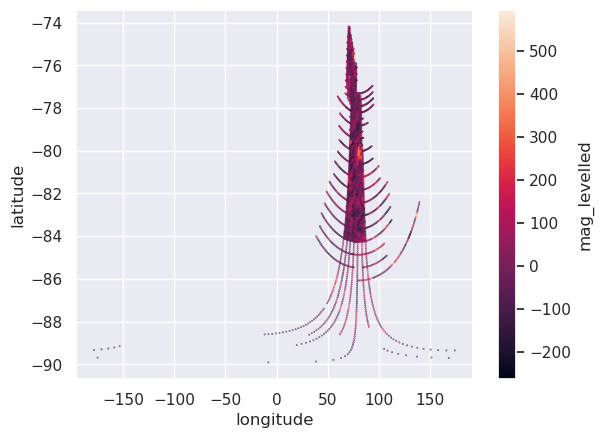

In [20]:
ax = data_df.plot.scatter(
    "longitude",
    "latitude",
    c="mag_levelled",
    s=0.1,
)

## Reproject

Since the original data is in lat / lon, the input CRS will be EPSG:4326, and we can reproject the data to EPSG 3031 - South Polar Stereographic, since the data is located in Antarctica.

In [21]:
data_df["easting"], data_df["northing"] = airbornegeo.reproject(
    data_df.longitude,
    data_df.latitude,
    input_crs="EPSG:4326",
    output_crs="EPSG:3031",
)
data_df.head()

,longitude,latitude,mag_levelled,line,unixtime,easting,northing
0,75.635869,-84.104145,-22.68,1,1.229500e+09,621099.093961,159056.748316
100,75.709950,-84.011406,-76.28,1,1.229501e+09,631094.016262,160747.130253
200,75.771279,-83.919180,-63.65,1,1.229501e+09,641004.786667,162541.084172
300,75.838380,-83.826748,-59.30,1,1.229501e+09,650959.222827,164254.115346
400,75.933132,-83.736291,-47.00,1,1.229501e+09,660790.608773,165572.968737


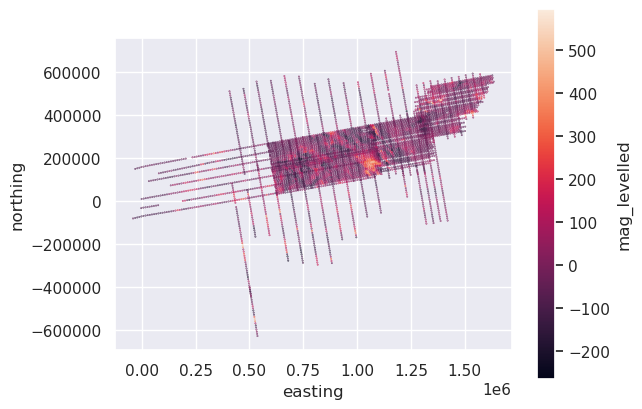

In [23]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="mag_levelled",
    s=0.1,
)
ax.set_aspect("equal")